# Monte Carlo Methods Using Class Implementation

This notebook uses the `MonteCarloSimulation` class for pricing Asian options using various Monte Carlo methods.

In [1]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt

## Initialize the Simulation

Create a simulation instance with our model parameters:

In [2]:
# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.04             # Risk-free rate
sigma = 2.0          # Volatility
gamma = 0.5          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 16          # Number of batches/scrambles

## Compare Different Methods

Comparison of standard MC and RQMC with the different variance reduction techniques:

In [3]:
# Using euler scheme
print("Using Euler scheme:\n")
results = sim.compare_methods(N, batches=batches, euler=True)

for method, stats in results.items():
    print(f"{method}:")
    print(f"  Price: {stats['mean']:.6f}")
    print(f"  SE: {stats['SE']:.8f}")
    print(f"  95% CI: [{stats['CI'][0]:.6f}, {stats['CI'][1]:.6f}]\n")

Using Euler scheme:

Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Standard MC:
  Price: 5.565630
  SE: 0.01972327
  95% CI: [5.523591, 5.607669]

Standard MC + Antithetic:
  Price: 5.541799
  SE: 0.01592572
  95% CI: [5.507854, 5.575744]

Standard MC + CV:
  Price: 5.562340
  SE: 0.01379952
  95% CI: [5.532927, 5.591753]

Standard MC + CV + Antithetic:
  Price: 5.540309
  SE: 0.00904444
  95% CI: [5.521031, 5.559586]

RQMC:
  Price: 5.540396
  SE: 0.00270845
  95% CI: [5.534623, 5.546169]

RQMC + CV:
  Price: 5.534697
  SE: 0.00729523
  95% CI: [5.519147, 5.550246]

RQMC + BB:
  Price: 5.544120
  SE: 0.00079541
  95% CI: [5.542425, 5.545816]

RQMC + BB + CV:
  Price: 5.543473
  SE: 0.00224264
  95% CI: [5.538692, 5.548253]



In [4]:
# Using milstein scheme
print("Using Milstein scheme:\n")
results = sim.compare_methods(N, batches=batches, euler=False)

for method, stats in results.items():
    print(f"{method}:")
    print(f"  Price: {stats['mean']:.6f}")
    print(f"  SE: {stats['SE']:.8f}")
    print(f"  95% CI: [{stats['CI'][0]:.6f}, {stats['CI'][1]:.6f}]\n")

Using Milstein scheme:

Estimated fixed beta from pilot RQMC: 0.045989
Estimated fixed beta from pilot RQMC: 0.045989
Standard MC:
  Price: 5.565228
  SE: 0.01974928
  95% CI: [5.523133, 5.607322]

Standard MC + Antithetic:
  Price: 5.541529
  SE: 0.01591398
  95% CI: [5.507609, 5.575448]

Standard MC + CV:
  Price: 5.561939
  SE: 0.01383152
  95% CI: [5.532458, 5.591421]

Standard MC + CV + Antithetic:
  Price: 5.540041
  SE: 0.00903021
  95% CI: [5.520793, 5.559288]

RQMC:
  Price: 5.540214
  SE: 0.00270914
  95% CI: [5.534440, 5.545989]

RQMC + CV:
  Price: 5.534519
  SE: 0.00729557
  95% CI: [5.518969, 5.550069]

RQMC + BB:
  Price: 5.543914
  SE: 0.00080828
  95% CI: [5.542191, 5.545636]

RQMC + BB + CV:
  Price: 5.543266
  SE: 0.00223340
  95% CI: [5.538506, 5.548026]



## Correlation Analysis

Let's analyze the correlation between the arithmetic Asian option payoff (our target) and the geometric Asian option payoff (our control variate):


Correlation Analysis:
Correlation between arithmetic and geometric payoffs: 0.7107

Arithmetic Payoff (X):
Mean: 5.5320
Std Dev: 7.5595

Geometric Payoff (Y):
Mean: 24.7733
Std Dev: 96.0990


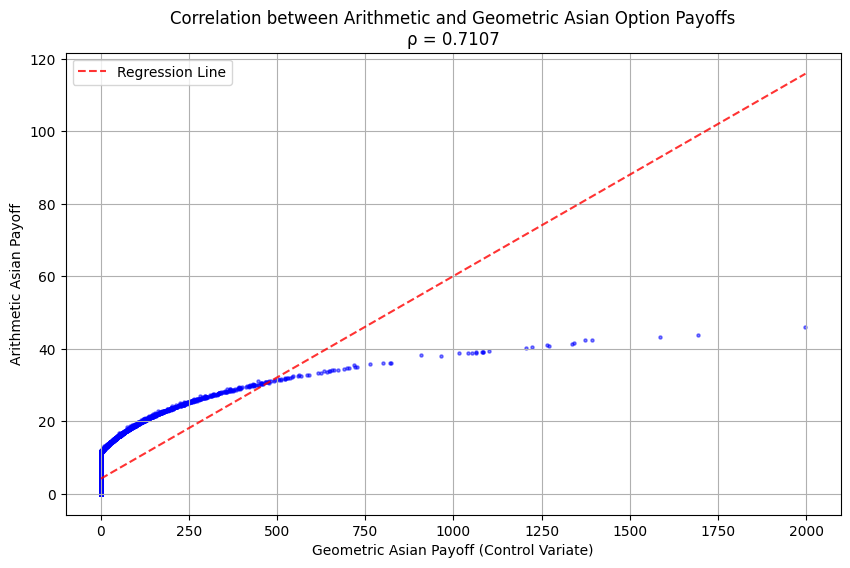

In [5]:
# Generate paths and compute payoffs
Z = sim.draw_quasi_random_numbers(sim.base_seed, N, sim.M)

# Simulate paths and compute payoffs for both arithmetic and geometric options
S_cev = sim.sim_CEV_paths(N, Z, euler=True)  # Using Euler scheme for CEV
X = np.exp(-sim.r*sim.T)*np.maximum(S_cev[:,1:].mean(1)-sim.K, 0.0)  # Arithmetic Asian payoff
Y = sim.sim_GBM_paths(N, Z)  # Geometric Asian payoff (control variate)

# Compute correlation
correlation = np.corrcoef(X, Y)[0,1]
print(f"\nCorrelation Analysis:")
print(f"Correlation between arithmetic and geometric payoffs: {correlation:.4f}")

# Basic statistics
print(f"\nArithmetic Payoff (X):")
print(f"Mean: {X.mean():.4f}")
print(f"Std Dev: {X.std():.4f}")
print(f"\nGeometric Payoff (Y):")
print(f"Mean: {Y.mean():.4f}")
print(f"Std Dev: {Y.std():.4f}")

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(Y, X, alpha=0.5, s=5, color='blue')
plt.xlabel('Geometric Asian Payoff (Control Variate)')
plt.ylabel('Arithmetic Asian Payoff')
plt.title(f'Correlation between Arithmetic and Geometric Asian Option Payoffs\nρ = {correlation:.4f}')
plt.grid(True)

# Add the regression line
z = np.polyfit(Y, X, 1)
p = np.poly1d(z)
y_range = np.linspace(Y.min(), Y.max(), 100)
plt.plot(y_range, p(y_range), 'r--', alpha=0.8, label='Regression Line')
plt.legend()

plt.show()

## Convergence Analysis

Plot of convergence for each method as we increase the number of paths:

Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019
Estimated fixed beta from pilot RQMC: 0.046019


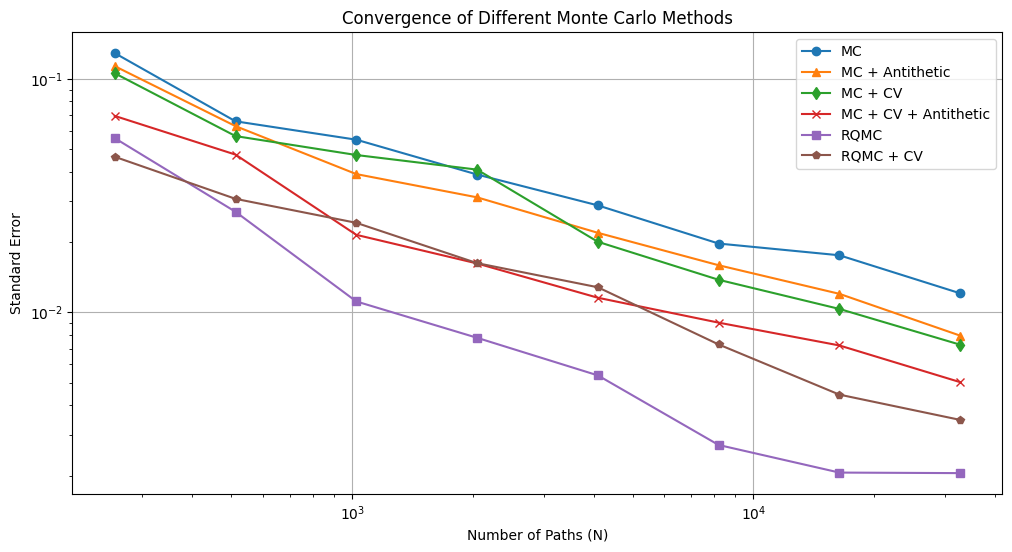

In [6]:
# Powers of 2 for QMC compatibility
N_values = [2**i for i in range(8, 16)]

# Get convergence data for each method
mc_prices, mc_errors = sim.plot_convergence(N_values, method='mc', batches=batches)
qmc_prices, qmc_errors = sim.plot_convergence(N_values, method='qmc', batches=batches)
mc_anti_prices, anti_errors = sim.plot_convergence(N_values, method='antithetic', batches=batches)
mc_cv_prices, cv_errors = sim.plot_convergence(N_values, method='mc + cv', batches=batches)
mc_cv_anti_prices, cv_anti_errors = sim.plot_convergence(N_values, method='mc + cv + antithetic', batches=batches)
qmc_cv_prices, qmc_cv_errors = sim.plot_convergence(N_values, method='qmc + cv', batches=batches)

# Plot results
plt.figure(figsize=(12, 6))
plt.loglog(N_values, mc_errors, 'o-', label='MC')
plt.loglog(N_values, anti_errors, '^-', label='MC + Antithetic')
plt.loglog(N_values, cv_errors, 'd-', label='MC + CV')
plt.loglog(N_values, cv_anti_errors, 'x-', label='MC + CV + Antithetic')
plt.loglog(N_values, qmc_errors, 's-', label='RQMC')
plt.loglog(N_values, qmc_cv_errors, 'p-', label='RQMC + CV')
plt.grid(True)
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Different Monte Carlo Methods')
plt.legend()
plt.show()

# Sensitivity Analysis
## Setup for sensitivty Analysis

In [7]:
#Compare MC vs RQMC Greeks
results = sim.compare_greeks_methods(N, batches=batches, euler=False)

S0=100
#Unpack MC results
(mc_delta_mean, mc_delta_se, mc_delta_ci, _, _ ), (mc_vega_mean, mc_vega_se, mc_vega_ci, _, _) = (results['Standard MC']['Delta'], results['Standard MC']['Vega']
)
print(f"MC   Delta mean: {mc_delta_mean:.6f}, 95% CI: [{mc_delta_ci[0]:.6f}, {mc_delta_ci[1]:.6f}], se: {mc_delta_se:.6f}")
print(f"MC   Vega  mean: {mc_vega_mean:.6f}, 95% CI: [{mc_vega_ci[0]:.6f}, {mc_vega_ci[1]:.6f}], se: {mc_vega_se:.6f}")

#Unpack RQMC results
(delta_mean, delta_se, delta_ci, _, _), (vega_mean, vega_se, vega_ci, _, _) = (
    results['RQMC']['Delta'], results['RQMC']['Vega']
)

print(f"RQMC Delta mean: {delta_mean:.6f}, 95% CI: [{delta_ci[0]:.6f}, {delta_ci[1]:.6f}], se: {delta_se:.6f}")
print(f"RQMC Vega  mean: {vega_mean:.6f}, 95% CI: [{vega_ci[0]:.6f}, {vega_ci[1]:.6f}], se: {vega_se:.6f}")


MC   Delta mean: 0.567711, 95% CI: [0.564439, 0.570983], se: 0.001535
MC   Vega  mean: 2.222801, 95% CI: [2.202598, 2.243005], se: 0.009479
RQMC Delta mean: 0.564584, 95% CI: [0.563094, 0.566073], se: 0.000699
RQMC Vega  mean: 2.213818, 95% CI: [2.209584, 2.218053], se: 0.001986


## Delta

In [8]:
# Delta
S0list = [80, 90, 100, 110, 120]
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, varbetween, _  = sim.mc_greeks_with_batches(N=2**15, batches=8, euler=False)[0]
    print(f"MC:  S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")
for Snull in S0list:
    sim.S0 = Snull
    price, se, ci, varbetween, _ = sim.rqmc_greeks_with_scrambles(N=2**15, scrambles=8, euler=False)[0]
    print(f"RQMC: S0={Snull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")


MC:  S0=80, Price=0.053255, 95% CI=[0.052358, 0.054153], SE=0.000380
MC:  S0=90, Price=0.240910, 95% CI=[0.238355, 0.243465], SE=0.001080
MC:  S0=100, Price=0.565902, 95% CI=[0.563501, 0.568303], SE=0.001015
MC:  S0=110, Price=0.834719, 95% CI=[0.833088, 0.836349], SE=0.000689
MC:  S0=120, Price=0.949684, 95% CI=[0.948770, 0.950598], SE=0.000386
RQMC: S0=80, Price=0.052857, 95% CI=[0.052056, 0.053658], SE=0.000339
RQMC: S0=90, Price=0.241012, 95% CI=[0.239739, 0.242285], SE=0.000538
RQMC: S0=100, Price=0.565977, 95% CI=[0.564761, 0.567193], SE=0.000514
RQMC: S0=110, Price=0.835862, 95% CI=[0.835038, 0.836686], SE=0.000348
RQMC: S0=120, Price=0.949713, 95% CI=[0.949115, 0.950312], SE=0.000253


## Vega

In [9]:
#Vega 
vegalist = [0.5, 1.0, 1.5, 2.0]
for sigmanull in vegalist:
    sim.sigma = sigmanull
    price, se, ci, varbetween, _ = sim.mc_greeks_with_batches(N=2**15, batches=8, euler=False)[1]
    print(f"MC:  sigma={sigmanull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")
for sigmanull in vegalist:
    sim.sigma = sigmanull
    price, se, ci, varbetween, _ = sim.rqmc_greeks_with_scrambles(N=2**15, scrambles=8, euler=False)[1]
    print(f"RQMC: sigma={sigmanull}, Price={price:.6f}, 95% CI=[{ci[0]:.6f}, {ci[1]:.6f}], SE={se:.6f}")

MC:  sigma=0.5, Price=-0.004599, 95% CI=[-0.041012, 0.031815], SE=0.015399
MC:  sigma=1.0, Price=-0.000752, 95% CI=[-0.037799, 0.036294], SE=0.015667
MC:  sigma=1.5, Price=0.115889, 95% CI=[0.077473, 0.154306], SE=0.016246
MC:  sigma=2.0, Price=0.424971, 95% CI=[0.389975, 0.459967], SE=0.014800
RQMC: sigma=0.5, Price=0.000011, 95% CI=[-0.000074, 0.000096], SE=0.000036
RQMC: sigma=1.0, Price=0.002656, 95% CI=[0.001379, 0.003933], SE=0.000540
RQMC: sigma=1.5, Price=0.118763, 95% CI=[0.113109, 0.124418], SE=0.002391
RQMC: sigma=2.0, Price=0.428983, 95% CI=[0.421413, 0.436552], SE=0.003201


## Plotting Convergence
### Delta Convergence

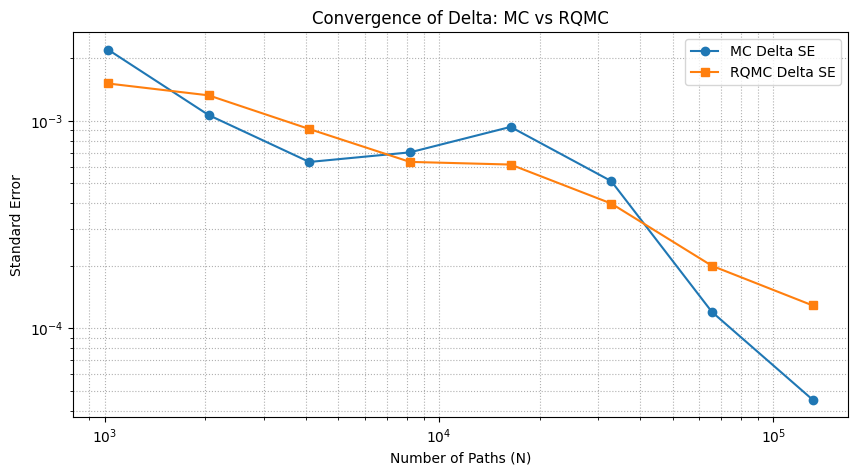

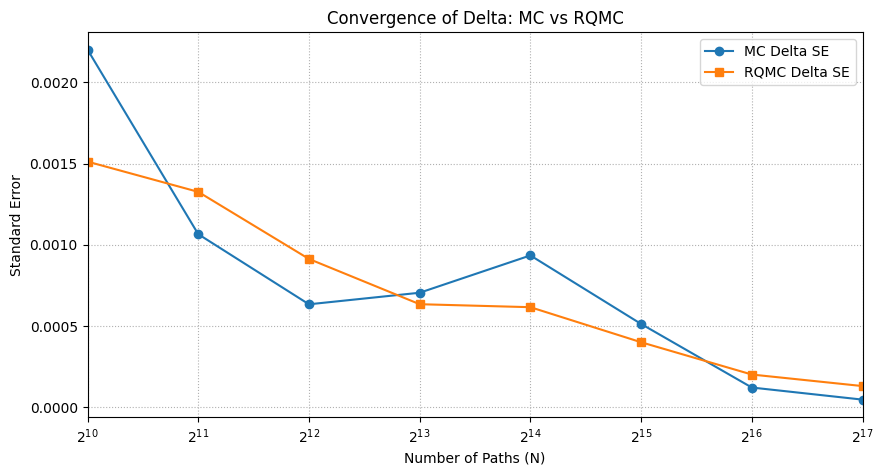

In [10]:
# Convergence of Delta (SE vs N) for MC vs RQMC
N_values = [2**i for i in range(10, 18)]  # 1024 to 131072
batches_plot = min(batches, 4)
scrambles_plot = min(batches, 4)

se_mc_delta = []
se_rqmc_delta = []

for N in N_values:
    # MC batches
    (d_mean_mc, d_se_mc, _, _, _), _ = sim.mc_greeks_with_batches(N, batches=batches_plot, euler=False)
    se_mc_delta.append(d_se_mc)

    # RQMC scrambles
    (d_mean_q, d_se_q, _, _, _), _ = sim.rqmc_greeks_with_scrambles(N, scrambles=scrambles_plot, euler=False)
    se_rqmc_delta.append(d_se_q)

plt.figure(figsize=(10, 5))
plt.loglog(N_values, se_mc_delta, 'o-', label='MC Delta SE')
plt.loglog(N_values, se_rqmc_delta, 's-', label='RQMC Delta SE')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Delta: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(np.log2(N_values), se_mc_delta, 'o-', label='MC Delta SE')
plt.plot(np.log2(N_values), se_rqmc_delta, 's-', label='RQMC Delta SE')
plt.xticks(np.log2(N_values), labels=[f'$2^{int(np.log2(n))}$' for n in N_values])
plt.xlim([np.log2(N_values[0]), np.log2(N_values[-1])])
plt.xticks(np.log2(N_values), labels=[f'$2^{{{int(np.log2(n))}}}$' for n in N_values])
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Delta: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

### Vega Convergence

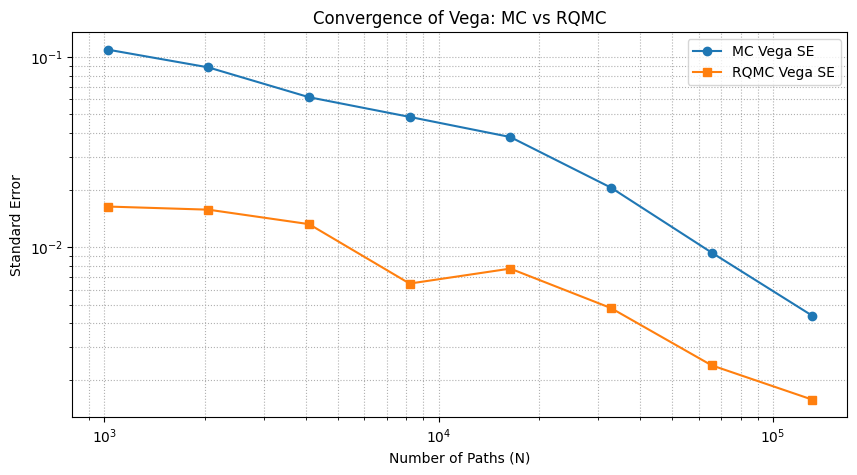

In [11]:
# Convergence of Vega (SE vs N) for MC vs RQMC
se_mc_vega = []
se_rqmc_vega = []

for N in N_values:
    # MC batches
    _, (v_mean_mc, v_se_mc, _, _, _) = sim.mc_greeks_with_batches(N, batches=batches_plot, euler=False)
    se_mc_vega.append(v_se_mc)

    # RQMC scrambles
    _, (v_mean_q, v_se_q, _, _, _) = sim.rqmc_greeks_with_scrambles(N, scrambles=scrambles_plot, euler=False)
    se_rqmc_vega.append(v_se_q)

plt.figure(figsize=(10, 5))
plt.loglog(N_values, se_mc_vega, 'o-', label='MC Vega SE')
plt.loglog(N_values, se_rqmc_vega, 's-', label='RQMC Vega SE')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Vega: MC vs RQMC')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()